<center>
    <img src="http://sct.inf.utfsm.cl/wp-content/uploads/2020/04/logo_di.png" style="width:40%">
    <h2> ILI-140 - Taller de Programación </h2>
    <h2> Caso anomalias en cañerías</h2>
    <h3> Grupo Butify </h3>
    <h3> 08/07/2025 </h3>
</center>

##### Integrantes
Nicolas Horta  
Nicolas Olivos  
Benjamin Pavez  
Ariel Pulgar  
Gabriel Saez  

In [43]:
pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [44]:
pip install pandas

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [45]:
pip install numpy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [46]:
pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [47]:
pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


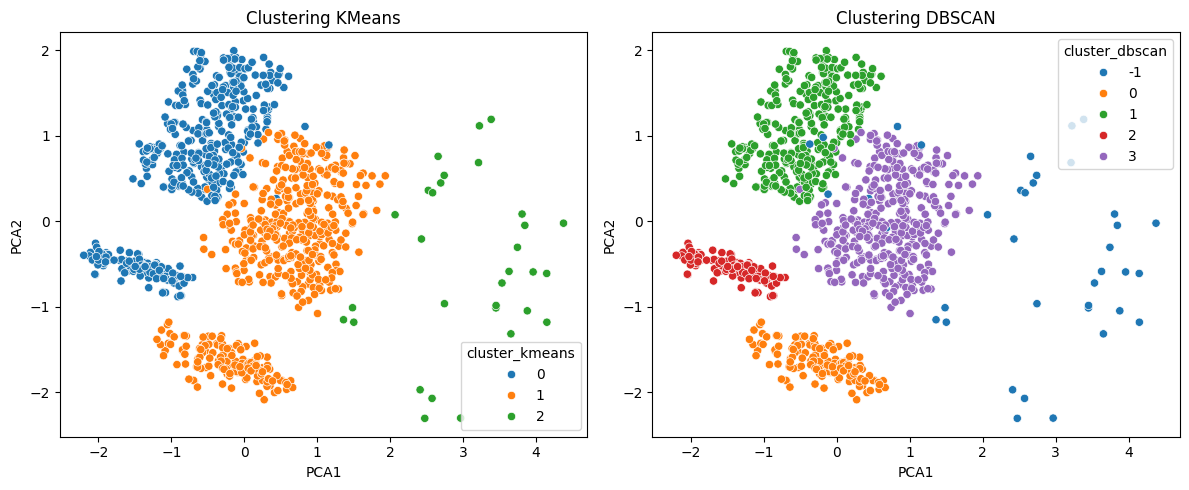

In [48]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cargar el dataset
df = pd.read_excel("water_leak_detection_1000_rows.xlsx")
#df = pd.read_excel("anomalia.xlsx")

# 2. Seleccionar variables de sensores

# Columnas de "water_leak_detection_1000_rows"
X = df[['Flow Rate (L/s)', 'Pressure (bar)', 'Temperature (°C)']]

# Columnas de "anomalia"
#X = df[['caudal', 'presion', 'temperatura']]

# Normalizar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster_kmeans'] = kmeans.fit_predict(X_scaled)

# DBSCAN clustering
dbscan = DBSCAN(eps=0.5, min_samples=10)
df['cluster_dbscan'] = dbscan.fit_predict(X_scaled)

# Visualizacion con PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df['PCA1'], df['PCA2'] = X_pca[:, 0], X_pca[:, 1]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='PCA1', y='PCA2', hue='cluster_kmeans', palette='tab10')
plt.title('Clustering KMeans')

plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='PCA1', y='PCA2', hue='cluster_dbscan', palette='tab10')
plt.title('Clustering DBSCAN')

plt.tight_layout()
plt.show()


In [49]:
# Verificar las columnas del dataset
print("Columnas del dataset:")
print(df.columns.tolist())
print("\nPrimeras 5 filas:")
print(df.head())

Columnas del dataset:
['Timestamp', 'Sensor_ID', 'Flow Rate (L/s)', 'Pressure (bar)', 'Temperature (°C)', 'Leak Status', 'Burst Status', 'cluster_kmeans', 'cluster_dbscan', 'PCA1', 'PCA2']

Primeras 5 filas:
            Timestamp Sensor_ID    Flow Rate (L/s)     Pressure (bar)  \
0 2024-01-01 00:00:00      S007   7751521847992457  36948144802903496   
1 2024-01-01 00:05:00      S007  17992642186624028  25871254182522992   
2 2024-01-01 00:10:00      S002   2101308230369969   2448964723482877   
3 2024-01-01 00:15:00      S009  14177793420835692   2936843710297063   
4 2024-01-01 00:20:00      S003  19748463287101824   3073692986900744   

   Temperature (°C)  Leak Status  Burst Status  cluster_kmeans  \
0      2.169537e+15            0             0               1   
1      1.901673e+15            0             0               1   
2      1.001168e+16            1             0               0   
3      1.209241e+16            0             0               0   
4      1.700144e+01    

# Clasificación supervisada


In [50]:
# Etiqueta binaria: 1 si hay fuga o ruptura, 0 si no
# Para el dataset water_leak_detection_1000_rows.xlsx
df['Falla'] = (df['Leak Status'] | df['Burst Status']).astype(int)

# Columnas de "water_leak_detection_1000_rows"
X = df[['Flow Rate (L/s)', 'Pressure (bar)', 'Temperature (°C)']]

# Columnas de "anomalia" (comentadas porque no estamos usando ese dataset)
#X = df[['caudal', 'presion', 'temperatura']]

**No ejecutar siguiente bloque si usas dataset "water_leak_detection_1000_rows"**

In [51]:
# KMeans con 3 clusters
kmeans = KMeans(n_clusters=3)
df['cluster'] = kmeans.fit_predict(X_scaled)

# Opción simple: considerar el clúster más pequeño como 'falla'
#cluster_counts = df['cluster'].value_counts()
#cluster_falla = cluster_counts.idxmin()

# Crear pseudoetiqueta
df['Falla'] = (df['cluster_dbscan'] == 1).astype(int)


In [52]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix

# Columnas de "water_leak_detection_1000_rows"
features = ['Flow Rate (L/s)', 'Pressure (bar)', 'Temperature (°C)', 'cluster_kmeans']

# Columnas de "anomalia" (comentadas porque no estamos usando ese dataset)
#features = ['caudal', 'presion', 'temperatura', 'cluster_kmeans']

X = df[features]
y = df['Falla']

# Dividir train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modelo Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Modelo Naive Bayes
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

# Resultados
print("Random Forest:\n", classification_report(y_test, y_pred_rf))
print("Naive Bayes:\n", classification_report(y_test, y_pred_nb))


Random Forest:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       142
           1       1.00      1.00      1.00        58

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

Naive Bayes:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99       142
           1       1.00      0.97      0.98        58

    accuracy                           0.99       200
   macro avg       0.99      0.98      0.99       200
weighted avg       0.99      0.99      0.99       200



In [53]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(hidden_layer_sizes=(50,), max_iter=500, random_state=42)
mlp.fit(X_train, y_train)
y_pred_mlp = mlp.predict(X_test)

print("MLP (Red Neuronal):\n", classification_report(y_test, y_pred_mlp))

MLP (Red Neuronal):
               precision    recall  f1-score   support

           0       0.99      1.00      1.00       142
           1       1.00      0.98      0.99        58

    accuracy                           0.99       200
   macro avg       1.00      0.99      0.99       200
weighted avg       1.00      0.99      0.99       200



# Creacion dato anomalo

In [54]:
anomalia_manual = pd.DataFrame([{
    'Flow Rate (L/s)': 9999,  # Valor anómalo para flujo
    'Pressure (bar)': 2,      # Valor anómalo para presión
    'Temperature (°C)': 200   # Valor anómalo para temperatura
}])
nuevo_dato_scaled = scaler.transform(anomalia_manual)

In [55]:
from sklearn.preprocessing import StandardScaler

X_original = df[['Flow Rate (L/s)', 'Pressure (bar)', 'Temperature (°C)']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_original)

anomalia_scaled = scaler.transform(anomalia_manual)

**Con cluster KMeans**

In [56]:
# KMeans con 3 clusteres
pred_cluster = kmeans.predict(anomalia_scaled)
print("Cluster asignado:", pred_cluster[0])

Cluster asignado: 2


**Con Cluster de DBSCAN**

In [57]:
# Suponiendo que ya entrenaste KMeans con 3 clusteres
nuevo_punto = [[9999, 2, 200]]  # Flow Rate, Pressure, Temperature

nuevo_punto_scaled = scaler.transform(nuevo_punto)

from sklearn.neighbors import NearestNeighbors

# Crear un indice de vecinos con los datos originales del clustering
nn = NearestNeighbors(n_neighbors=dbscan.min_samples)
nn.fit(X_scaled)

# Calcular las distancias al nuevo punto
distancias, indices = nn.kneighbors(nuevo_punto_scaled)

# Evaluar si la distancia al k-esimo vecino es menor que eps
if distancias[0][-1] <= dbscan.eps:
    print("El nuevo punto pertenece a clúster (NORMAL).")
else:
    print("El nuevo punto es un outlier (ANOMALÍA).")


El nuevo punto pertenece a clúster (NORMAL).


/home/benja_p/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [58]:
es_anomalia = int(distancias[0][-1] > dbscan.eps)
print("Etiqueta:", es_anomalia)  # 1 = anómalo, 0 = normal

Etiqueta: 0


**Test con IsolationForest**

In [59]:
from sklearn.ensemble import IsolationForest

# Entrenar el modelo con el dataset original
isof = IsolationForest(contamination=0.05, random_state=42)
isof.fit(X_scaled)

# Predecir anomalia
pred = isof.predict(anomalia_scaled)
print("¿Es una anomalía?", pred[0] == -1)


¿Es una anomalía? True


# Test Modelo Supervisado???

In [60]:
cluster_nuevo = kmeans.predict(nuevo_dato_scaled)
anomalia_manual['cluster_kmeans'] = cluster_nuevo

In [61]:
print(anomalia_manual.columns)

Index(['Flow Rate (L/s)', 'Pressure (bar)', 'Temperature (°C)',
       'cluster_kmeans'],
      dtype='object')


In [62]:
X_nuevo = anomalia_manual[features]

# Predecir si hay falla
pred = rf.predict(X_nuevo)
print("¿Falla detectada?", pred[0] == 1)

¿Falla detectada? False


## Modelos Supervisados: Random Forest y Naive Bayes

In [63]:

# Usaremos la pseudoetiqueta 'Falla' generada previamente como variable objetivo

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_scaled, df['Falla'], test_size=0.3, random_state=42)

# Modelo Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

# Modelo Naive Bayes
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

print("Naive Bayes")
print(confusion_matrix(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))


Random Forest
[[206   0]
 [  0  94]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       206
           1       1.00      1.00      1.00        94

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300

Naive Bayes
[[206   0]
 [  1  93]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       206
           1       1.00      0.99      0.99        94

    accuracy                           1.00       300
   macro avg       1.00      0.99      1.00       300
weighted avg       1.00      1.00      1.00       300



## Clustering Jerárquico

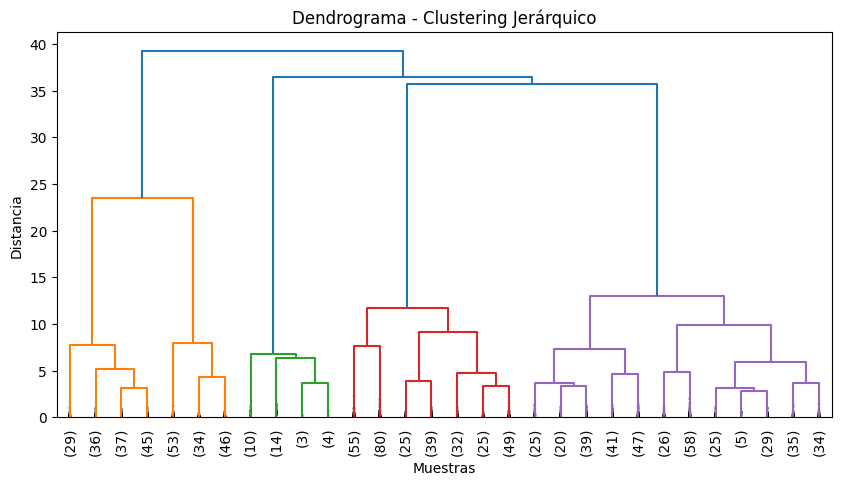

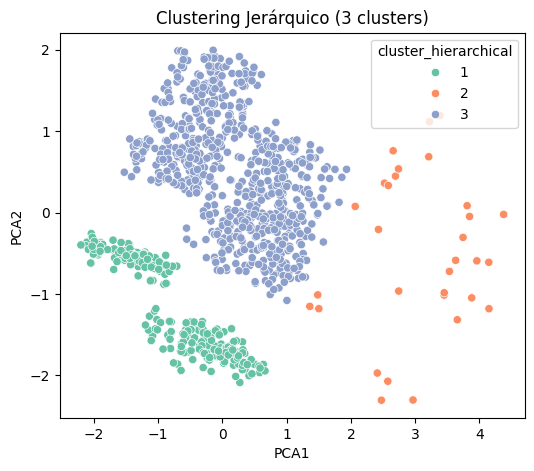

In [64]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# Clustering jerárquico con el método de enlace completo
linked = linkage(X_scaled, method='ward')

# Visualizar dendrograma
plt.figure(figsize=(10, 5))
dendrogram(linked, truncate_mode='lastp', p=30, leaf_rotation=90., leaf_font_size=10., show_contracted=True)
plt.title('Dendrograma - Clustering Jerárquico')
plt.xlabel('Muestras')
plt.ylabel('Distancia')
plt.show()

# Asignar clusters (por ejemplo, 3)
df['cluster_hierarchical'] = fcluster(linked, 3, criterion='maxclust')

# Visualización en espacio PCA
plt.figure(figsize=(6, 5))
sns.scatterplot(x=df['PCA1'], y=df['PCA2'], hue=df['cluster_hierarchical'], palette='Set2')
plt.title('Clustering Jerárquico (3 clusters)')
plt.show()
